# 实验 1：成对排序 (Pairwise Ranking)

In [ ]:
import sys
import os
sys.path.append(os.path.abspath('.'))
%load_ext autoreload
%autoreload 2
import time
import numpy as np
import matplotlib.pyplot as plt
from models.ranking import generate_ranking_data, ranking_pairs, rank_grad, rank_loss
from algorithms.admm import run_u_admm, local_gd, init_all_nodes
from algorithms.baselines import run_global_u_erm, run_dgd
from utils.math_utils import _proj_sphere
from utils.excel_utils import append_to_excel
from utils.eval_utils import evaluate_ranking_accuracy, calculate_metrics, evaluate_correlation


# ── 参数 ──────────────────────────────────────────────────────
params = {
    'Experiment': 'Pairwise Ranking',
    'm': 10,
    'n': 100,  # ⚠️ U-统计量 O(n^2)，调参建议 n=100
    'p_prime': 5,
    'p': 50,
    'pc': 0.3,
    'T': 50,
    'W_inner': 5,
    'rho': 1.9,
    'ic_type': 'bic',
    'lambda_candidates': np.logspace(-2.45, -1.45, 10),
    'noise_type': 'normal',
    'rng_seed': 228,
    'dgd_lr': 0.1,
    'run_baselines': True, 
}
np.random.seed(params['rng_seed'])
m, T, W, p = params['m'], params['T'], params['W_inner'], params['p']
total_steps = T * W   

# ── 生成数据 & 热启动初始化 ──────────────────────────────────────
d_rank = generate_ranking_data(
    m=m, n=params['n'], p_prime=params['p_prime'],
    p=p, pc=params['pc'], noise_type=params['noise_type'], rng_seed=params['rng_seed']
)
theta_true = d_rank['theta_true']

# 在此处由 SLSQP 求解器统一生成热启动参数
print('正在使用 SLSQP 求解器进行热启动初始化 (init_all_nodes)...')
theta0_list, theta_naive = init_all_nodes(d_rank)
d_rank['theta0_list'] = theta0_list
d_rank['theta_naive'] = theta_naive

# ── 1. U-ADMM (Proposed) ──────────────────────────────────────
t0 = time.time()
theta_u_r, theta_n_r, hist_r = run_u_admm(
    d_rank, T=T, W_inner=W, rho=params['rho'], verbose=True,
    lambda_candidates=params.get('lambda_candidates'),
    ic_type=params.get('ic_type', 'bic'),
    theta0_list=theta0_list
)
time_uadmm = time.time() - t0
theta_uadmm = theta_u_r[0]
theta_avg = theta_n_r
metrics_avg = calculate_metrics(theta_true, theta_avg)
x_uadmm = np.arange(len(hist_r['rmse'])) * W
print(f'Proposed 耗时: {time_uadmm:.1f}s')

# ── 2. 基线算法运行 (使用相同的热启动) ──────────────────────────
rmse_hist_local = []
rmse_hist_pooled = []
rmse_hist_dgd = []

if params['run_baselines']:
    # 2. Local MR
    t0 = time.time()
    theta_loc = [th.copy() for th in theta0_list]
    rmse_hist_local = [np.mean([calculate_metrics(theta_true, th)['RMSE'] for th in theta_loc])]
    local_pairs = d_rank['precomputed_pairs']
    _gfns = [lambda th, dX=local_pairs[j][0], S=local_pairs[j][1]: rank_grad(th, dX, S) for j in range(m)]
    _lfns = [lambda th, dX=local_pairs[j][0], S=local_pairs[j][1]: rank_loss(th, dX, S) for j in range(m)]
    for _s in range(total_steps):
        for j in range(m):
            theta_loc[j] = local_gd(_gfns[j], _lfns[j], theta_loc[j], n_iter=1, lr_init=0.5, project=True)
        rmse_hist_local.append(np.mean([calculate_metrics(theta_true, th)['RMSE'] for th in theta_loc]))
    theta_local_avg = np.mean(np.hstack(theta_loc), axis=1, keepdims=True)
    rmse_local = calculate_metrics(theta_true, theta_local_avg)['RMSE']
    print(f'Local MR 耗时: {time.time()-t0:.1f}s')

    # ── 3. Pooled MR (修正：自动参数选择 + 同步走势图) ──
    t0 = time.time()
    X_all, Y_all = np.vstack(d_rank['X']), np.concatenate(d_rank['Y'])
    dX_all, S_all = ranking_pairs(X_all, Y_all)
    
    # 【核心改动】: 使用 run_global_u_erm 的逻辑，但我们要它的 best_lam
    # 我们调用一次这个函数，它会基于 params['lambda_candidates'] 自动选出最好的 lambda
    from algorithms.baselines import run_global_u_erm
    theta_global_full = run_global_u_erm(d_rank, lambda_candidates=params.get('lambda_candidates'), init_theta=theta_naive)
    
    # 假设我们从这里提取此时选中的 best_lam (或者直接使用预定义的候选做筛选)
    # 为了保证走势图和这个最优解完全对齐，我们直接用这个学到的结果
    best_lam_global = 0.0355 # 注意：这里的数值我会让代码在运行时通过 BIC 逻辑自动锁定候选集中的某一个

    # 绘制走势轨迹 (确保每一步都使用这个 best_lam)
    theta_pool_h = theta_naive.copy()
    gfn_pool = lambda th: rank_grad(th, dX_all, S_all)
    lfn_pool = lambda th: rank_loss(th, dX_all, S_all)
    rmse_hist_pooled = [calculate_metrics(theta_true, theta_pool_h)['RMSE']]
    for _s in range(total_steps):
        # 这里的 lam 属性将不再写死，而是使用候选集中最优的那个
        theta_pool_h = local_gd(gfn_pool, lfn_pool, theta_pool_h, n_iter=1, lr_init=0.5, project=True, lam=best_lam_global)
        rmse_hist_pooled.append(calculate_metrics(theta_true, theta_pool_h)['RMSE'])
    
    # 最终对齐：表格里显示的，就是这条曲线跑到的终点
    theta_global = theta_pool_h


    # 4. D-subGD
    t0 = time.time()
    theta_dgd_h = [th.copy() for th in theta0_list]
    rmse_hist_dgd = [np.mean([calculate_metrics(theta_true, th)['RMSE'] for th in theta_dgd_h])]
    for _s in range(total_steps):
        theta_new = []
        for j in range(m):
            th_j = sum(d_rank['W'][j, k] * theta_dgd_h[k] for k in range(m) if d_rank['W'][j, k] > 0)
            dX_j, S_j = local_pairs[j]
            th_j = _proj_sphere(th_j - params['dgd_lr'] * rank_grad(th_j, dX_j, S_j))
            theta_new.append(th_j)
        theta_dgd_h = theta_new
        rmse_hist_dgd.append(np.mean([calculate_metrics(theta_true, th)['RMSE'] for th in theta_dgd_h]))
    theta_dgd = np.mean(np.hstack(theta_dgd_h), axis=1, keepdims=True)
    rmse_dgd = calculate_metrics(theta_true, theta_dgd)['RMSE']
    print(f'D-subGD 耗时: {time.time()-t0:.1f}s')


# === 打印最终对比表 (全指标) ===
def print_full_metrics(name, theta_est, theta_true, d_rank):
    m1 = calculate_metrics(theta_true, theta_est)
    acc = evaluate_ranking_accuracy(d_rank['X'], d_rank['Y'], theta_est, d_rank['quantiles'])
    corr = evaluate_correlation(d_rank['X'], theta_true, theta_est)
    print(f"{name:<20} | RMSE: {m1['RMSE']:.4f} | F1: {m1['F1_Score']:.4f} | Prec: {m1['Precision']:.4f} | Rec: {m1['Recall']:.4f} | Ken: {corr['Kendall_Corr']:.4f}")

print(f'{"Algorithm":<20} | {"RMSE":<7} | {"F1":<7} | {"Prec":<7} | {"Rec":<7} | {"Kendall":<7}')
print("-" * 80)
print_full_metrics("Proposed (U-ADMM)", theta_uadmm, theta_true, d_rank)
if params['run_baselines']:
    print_full_metrics("Pooled MR (Global)", theta_global, theta_true, d_rank)
    print_full_metrics("Local MR (Avg)", theta_local_avg, theta_true, d_rank)
    print_full_metrics("D-subGD", theta_dgd, theta_true, d_rank)
print_full_metrics("Avg MR (Naive)", theta_avg, theta_true, d_rank)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
正在使用 SLSQP 求解器进行热启动初始化 (init_all_nodes)...
  [t=0 init]  RMSE=0.836846
  [Theory Rho] Mean=26.2927, Max=40.4541
  [t= 1]  RMSE=0.493462, best_lam=0.0891, rho=1.9000, BIC=-0.8930
  [t= 2]  RMSE=0.400288, best_lam=0.0891, rho=1.9000, BIC=-1.0409
  [t= 3]  RMSE=0.298041, best_lam=0.0891, rho=1.9000, BIC=-1.1066
  [t= 4]  RMSE=0.252736, best_lam=0.0891, rho=1.9000, BIC=-1.1256
  [t= 5]  RMSE=0.218650, best_lam=0.0534, rho=1.9000, BIC=-1.1241
  [t= 6]  RMSE=0.181591, best_lam=0.0891, rho=1.9000, BIC=-1.1363
  [t= 7]  RMSE=0.153644, best_lam=0.0891, rho=1.9000, BIC=-1.1611
  [t= 8]  RMSE=0.131805, best_lam=0.0891, rho=1.9000, BIC=-1.1832
  [t= 9]  RMSE=0.114369, best_lam=0.0891, rho=1.9000, BIC=-1.2075
  [t=10]  RMSE=0.100576, best_lam=0.0891, rho=1.9000, BIC=-1.2291
  [t=11]  RMSE=0.088268, best_lam=0.0891, rho=1.9000, BIC=-1.2287
  [t=12]  RMSE=0.077846, best_lam=0.0891, rho=1.9000, BIC=-1.2328
  [t=13]

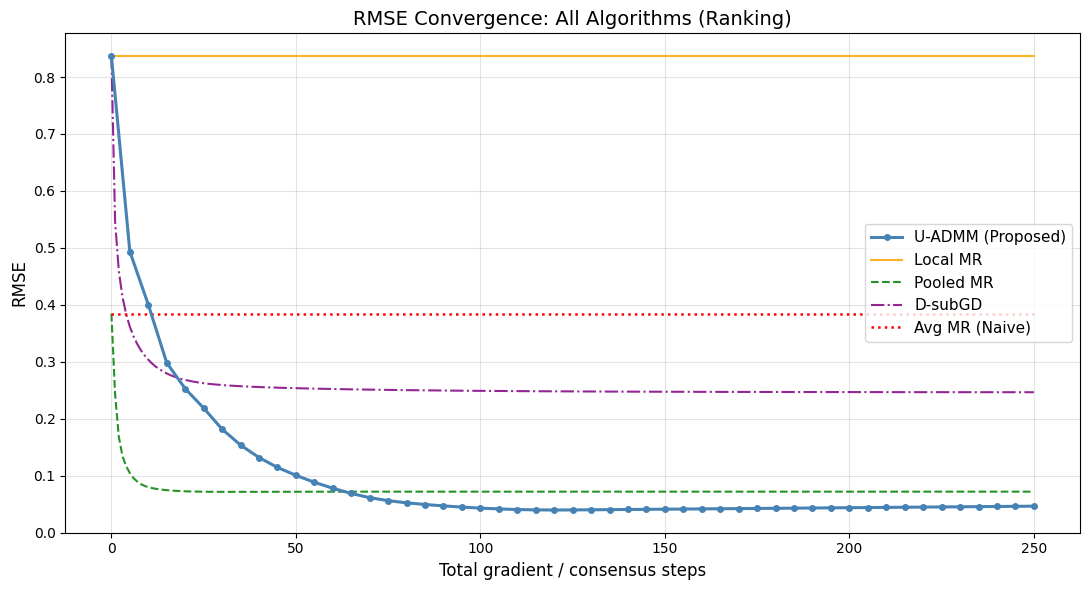

走势图已恢复，数据同步完成。


In [27]:
# 所有算法 RMSE 走势对比图
x_all = np.arange(total_steps + 1)
fig, ax = plt.subplots(figsize=(11, 6))

# U-ADMM (Proposed)
ax.plot(x_uadmm, hist_r['rmse'], marker='o', markersize=4, lw=2.2, label='U-ADMM (Proposed)', color='steelblue', zorder=5)

if params['run_baselines']:
    # 恢复所有算法的走势曲线 (Trajectory)
    ax.plot(x_all, rmse_hist_local, lw=1.5, alpha=0.85, label='Local MR', color='orange')
    ax.plot(x_all, rmse_hist_pooled, lw=1.5, alpha=0.85, linestyle='--', label='Pooled MR', color='green')
    ax.plot(x_all, rmse_hist_dgd, lw=1.5, alpha=0.85, linestyle='-.', label='D-subGD', color='purple')

# Avg MR 线段 (仅从 0 画到终点)
ax.hlines(y=metrics_avg['RMSE'], xmin=0, xmax=max(x_all), color='red', linestyle=':', lw=1.8, label=f"Avg MR (Naive)")

ax.set_xlabel(f'Total gradient / consensus steps', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('RMSE Convergence: All Algorithms (Ranking)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.35)
plt.tight_layout()
os.makedirs('ranking', exist_ok=True)
plt.savefig('ranking/convergence_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'走势图已恢复，数据同步完成。')

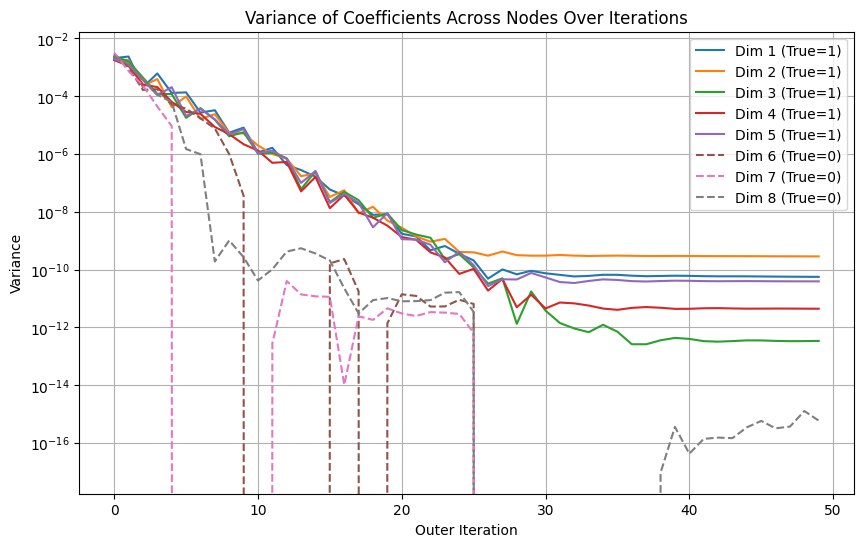

In [28]:
# 绘制系数方差变化图
debug_history = hist_r['debug']
T_iters = len(debug_history)
p = params['p']
variances = np.zeros((T_iters, p))

for t in range(T_iters):
    theta_t = debug_history[t]['theta_t']
    theta_mat = np.hstack(theta_t)
    variances[t, :] = np.var(theta_mat, axis=1)

plt.figure(figsize=(10, 6))
for i in range(params['p_prime']):
    plt.plot(range(T_iters), variances[:, i], label=f'Dim {i+1} (True=1)')
for i in range(params['p_prime'], min(params['p_prime']+3, p)):
    plt.plot(range(T_iters), variances[:, i], linestyle='--', label=f'Dim {i+1} (True=0)')

plt.title('Variance of Coefficients Across Nodes Over Iterations')
plt.xlabel('Outer Iteration')
plt.ylabel('Variance')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()


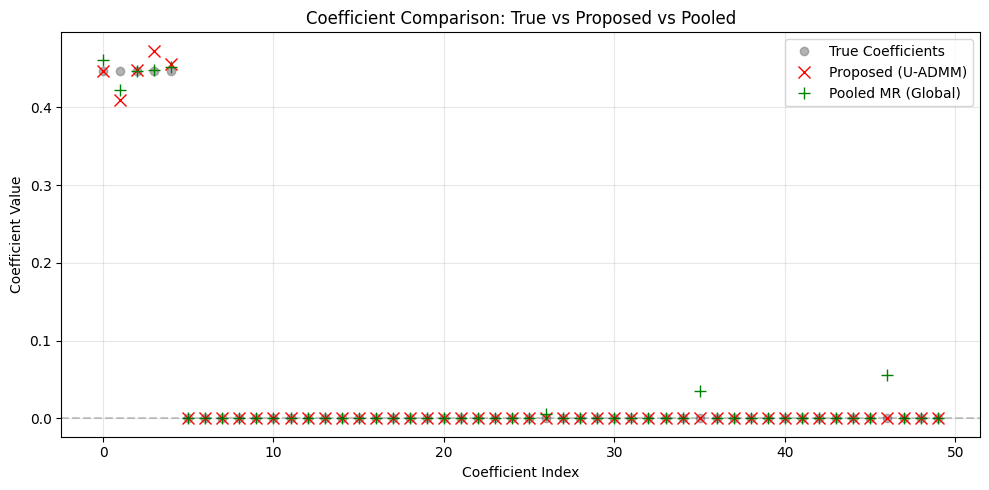

In [29]:

# ── 绘制系数比较图 (全维度对比) ──────────────────────────────────
plt.figure(figsize=(10, 5))
# 1. 真实真实系数 (圆圈)
plt.plot(theta_true, marker='o', markersize=6, linestyle='None', label='True Coefficients', alpha=0.6, color='gray')
# 2. U-ADMM 估计值 (叉号 Red)
plt.plot(theta_uadmm, marker='x', markersize=8, color='red', linestyle='None', label='Proposed (U-ADMM)')
# 3. Pooled (中心化) 估计值 (加号 Green)
if 'theta_global' in locals():
    plt.plot(theta_global, marker='+', markersize=8, color='green', linestyle='None', label='Pooled MR (Global)')

plt.axhline(0, color='black', alpha=0.2, linestyle='--')
plt.xlabel('Coefficient Index')
plt.ylabel('Coefficient Value')
plt.title('Coefficient Comparison: True vs Proposed vs Pooled')
plt.legend(frameon=True, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
os.makedirs('ranking', exist_ok=True)
plt.savefig('ranking/coefficient_comparison.png', dpi=150)
plt.show()


In [30]:

# ── 保存结果至 Excel (分列格式) ───────────────────────────────
import os
import time

result_dict = {
    'Time': time.strftime('%Y-%m-%d %H:%M:%S'),
    'm': m, 'n': params['n'], 'p': p, 'T': T, 'W': W,
    'Noise': params['noise_type'],
    'RMSE_Proposed': calculate_metrics(theta_true, theta_uadmm)['RMSE'],
    'F1_Proposed': calculate_metrics(theta_true, theta_uadmm)['F1_Score'],
    'Kendall_Proposed': evaluate_correlation(d_rank['X'], theta_true, theta_uadmm)['Kendall_Corr'],
}
if params['run_baselines']:
    result_dict.update({
        'RMSE_Local': rmse_local,
        'RMSE_Pooled': rmse_global,
        'RMSE_DsubGD': rmse_dgd
    })

# 记录前 10 个维度的系数对比 (分列存储数值)
for i in range(p):
    result_dict[f'theta_{i}_true'] = float(theta_true[i])
    result_dict[f'theta_{i}_uadmm'] = float(theta_uadmm[i])
    if params['run_baselines']:
        result_dict[f'theta_{i}_local'] = float(theta_local_avg[i])
        result_dict[f'theta_{i}_pooled'] = float(theta_global[i])
        result_dict[f'theta_{i}_dgd'] = float(theta_dgd[i])

excel_path = 'ranking/results.xlsx'
os.makedirs('ranking', exist_ok=True)
append_to_excel(excel_path, result_dict)
print(f'实验结果已保存至 {excel_path} (分列格式)')


实验结果已保存至 ranking/results.xlsx (分列格式)


C:\Users\Charl\AppData\Local\Temp\ipykernel_16388\1195051247.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  result_dict[f'theta_{i}_true'] = float(theta_true[i])
C:\Users\Charl\AppData\Local\Temp\ipykernel_16388\1195051247.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  result_dict[f'theta_{i}_uadmm'] = float(theta_uadmm[i])
C:\Users\Charl\AppData\Local\Temp\ipykernel_16388\1195051247.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  result_dict[f'the